# 3.2 — Regression Modelling (from 2.2 data-preparation UMAP/MICE)

This notebook performs a comprehensive regression modelling workflow using the prepared dataset output from `2.2-data-preparation-UMAP-Mice.ipynb` (train/test parquet files). 

Goals:

1. Load cleaned data.
2. Explore target and features.
3. Build and evaluate regression models.
4. Produce explainable output (feature importance + SHAP optionally).
5. Save best model and metrics.

In [2]:
# 1. Imports and global setup
import os
from pathlib import Path

import pandas as pd
import numpy as np
import polars as pl

from sklearn.model_selection import train_test_split, RepeatedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

# Optional explainability library
try:
    import shap
except Exception:
    shap = None

pd.options.display.max_columns = 200
pd.options.display.precision = 4

print('Libraries loaded. SHAP installed:', shap is not None)

c:\Users\jkrin\.pyenv\pyenv-win\versions\3.12.2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded. SHAP installed: True


In [3]:
# 2. Load data from parquet outputs


# Polars to pandas for sklearn convenience
train_pl = pl.read_parquet(f"./data/interim/2.2-train.parquet")
test_pl = pl.read_parquet(f"./data/interim/2.2-test.parquet")

print('Train shape:', train_pl.shape)
print('Test shape:', test_pl.shape)

train_df = train_pl.to_pandas()
test_df = test_pl.to_pandas()

print('Top columns:', list(train_df.columns[:20]))

# quick view for 5 rows
display(train_df.head())

Train shape: (111388, 48)
Test shape: (27848, 48)
Top columns: ['Arthritis', 'Cancer', 'Circulation', 'Depression', 'Diabetes', 'Heart Disease', 'High Bp', 'Kidney Disease', 'Liver Disease', 'Lung Disease', 'Nervous System', 'Stroke', 'Pre-Op Q Assisted', 'Pre-Op Q Previous Surgery', 'Age Band', 'Gender', 'Pre-Op Q Symptom Period', 'Pre-Op Q Mobility', 'Pre-Op Q Self-Care', 'Pre-Op Q Activity']


,Arthritis,Cancer,Circulation,Depression,Diabetes,Heart Disease,High Bp,Kidney Disease,Liver Disease,Lung Disease,Nervous System,Stroke,Pre-Op Q Assisted,Pre-Op Q Previous Surgery,Age Band,Gender,Pre-Op Q Symptom Period,Pre-Op Q Mobility,Pre-Op Q Self-Care,Pre-Op Q Activity,Pre-Op Q Discomfort,Pre-Op Q Anxiety,Pre-Op Q EQ5D Index,Post-Op Q EQ5D Index,Knee Replacement Pre-Op Q Pain,Knee Replacement Pre-Op Q Night Pain,Knee Replacement Pre-Op Q Washing,Knee Replacement Pre-Op Q Transport,Knee Replacement Pre-Op Q Walking,Knee Replacement Pre-Op Q Standing,Knee Replacement Pre-Op Q Limping,Knee Replacement Pre-Op Q Kneeling,Knee Replacement Pre-Op Q Work,Knee Replacement Pre-Op Q Confidence,Knee Replacement Pre-Op Q Shopping,Knee Replacement Pre-Op Q Stairs,Knee Replacement Post-Op Q Score,Pre-Op Q Living Arrangements,Pre-Op Q Disability,Provider Code,Procedure,Revision Flag,Year,Pre-Op Q Assisted By,Knee Replacement Pre-Op Q Score,Pre-Op Q EQ5D Index Profile,Post-Op Q EQ5D Index Profile,health_gain
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,3.0,2.0,1.0,2.0,2.0,2.0,3.0,2.0,-0.016,1.0000,0.0,0.0,2.0,2.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,40.0,1.0,1.0,294.0,1.0,0.0,3.0,1.0,9.0,22232,11111,31.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,4.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,0.796,0.7600,1.0,2.0,4.0,4.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,29.0,1.0,2.0,183.0,1.0,0.0,3.0,1.0,33.0,11121,11221,-4.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,4.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,0.796,1.0000,1.0,3.0,4.0,4.0,2.0,3.0,2.0,2.0,3.0,3.0,3.0,3.0,35.0,1.0,2.0,267.0,1.0,0.0,1.0,1.0,33.0,11121,11111,2.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,4.0,1.0,4.0,2.0,1.0,2.0,2.0,1.0,0.691,0.6910,0.0,0.0,3.0,2.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,43.0,1.0,1.0,274.0,1.0,0.0,2.0,1.0,11.0,21221,21221,32.0
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,3.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,0.691,0.9065,1.0,1.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,3.0,43.0,1.0,1.0,156.0,1.0,0.0,1.0,1.0,26.0,21221,11291,17.0


## 3. Data overview and missingness

In [4]:
# Null counts
print('Train nulls:')
print(train_df.isna().sum()[train_df.isna().sum() > 0].sort_values(ascending=False))
print('\nTest nulls:')
print(test_df.isna().sum()[test_df.isna().sum() > 0].sort_values(ascending=False))

# Basic descriptive stats
print('\nTrain numeric stats:')
print(train_df.describe().T.head(20))

Train nulls:
Series([], dtype: int64)

Test nulls:
Series([], dtype: int64)

Train numeric stats:
                              count    mean     std     min  25%  50%  75%  \
Arthritis                  111388.0  0.7695  0.4211  0.0000  1.0  1.0  1.0   
Cancer                     111388.0  0.0542  0.2264  0.0000  0.0  0.0  0.0   
Circulation                111388.0  0.0568  0.2314  0.0000  0.0  0.0  0.0   
Depression                 111388.0  0.0941  0.2920  0.0000  0.0  0.0  0.0   
Diabetes                   111388.0  0.1251  0.3308  0.0000  0.0  0.0  0.0   
Heart Disease              111388.0  0.0940  0.2919  0.0000  0.0  0.0  0.0   
High Bp                    111388.0  0.4417  0.4966  0.0000  0.0  0.0  1.0   
Kidney Disease             111388.0  0.0204  0.1415  0.0000  0.0  0.0  0.0   
Liver Disease              111388.0  0.0058  0.0759  0.0000  0.0  0.0  0.0   
Lung Disease               111388.0  0.0923  0.2894  0.0000  0.0  0.0  0.0   
Nervous System             111388.0  0.0105 

### 3.1 Select regression target

Typical targets in this pipeline are:
- `Hip Replacement Post-Op Q Score` (continuous)
- `Hip Replacement Pre-Op Q Score` normally pre-existing
- `OHS_Success` is binary (classification), so we will keep this aside.

We will model post-op score as a regression target.

Selected target: health_gain


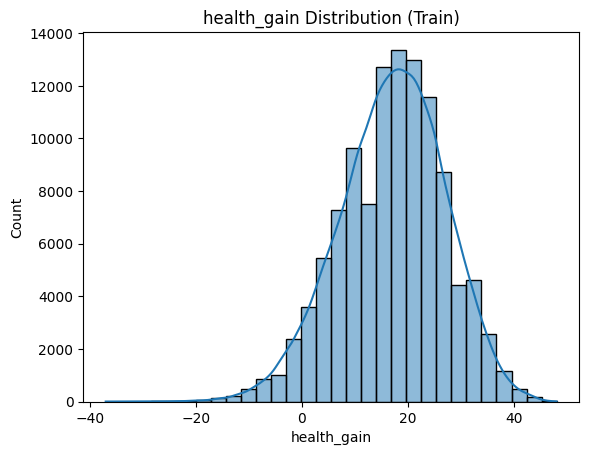

Target stats (train): count    111388.0000
mean         17.0267
std           9.9236
min         -37.0000
25%          11.0000
50%          17.0980
75%          24.0000
max          48.0000
Name: health_gain, dtype: float64
Top 15 positive correlations with target:
Knee Replacement Post-Op Q Score    0.6729
Post-Op Q EQ5D Index                0.4643
Pre-Op Q Discomfort                 0.2677
Pre-Op Q Activity                   0.1794
Pre-Op Q Mobility                   0.1608
Pre-Op Q Self-Care                  0.0838
Pre-Op Q Previous Surgery           0.0786
Gender                              0.0426
Year                                0.0336
Arthritis                           0.0264
Age Band                            0.0195
Pre-Op Q Anxiety                    0.0174
Pre-Op Q Symptom Period             0.0068
High Bp                             0.0048
Cancer                              0.0008
Name: health_gain, dtype: float64

Top 15 negative correlations with target:
Knee Replace

C:\Users\jkrin\AppData\Local\Temp\ipykernel_24892\2149507075.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd.DataFrame({'corr': top_pos.values, 'feature': top_pos.index}),


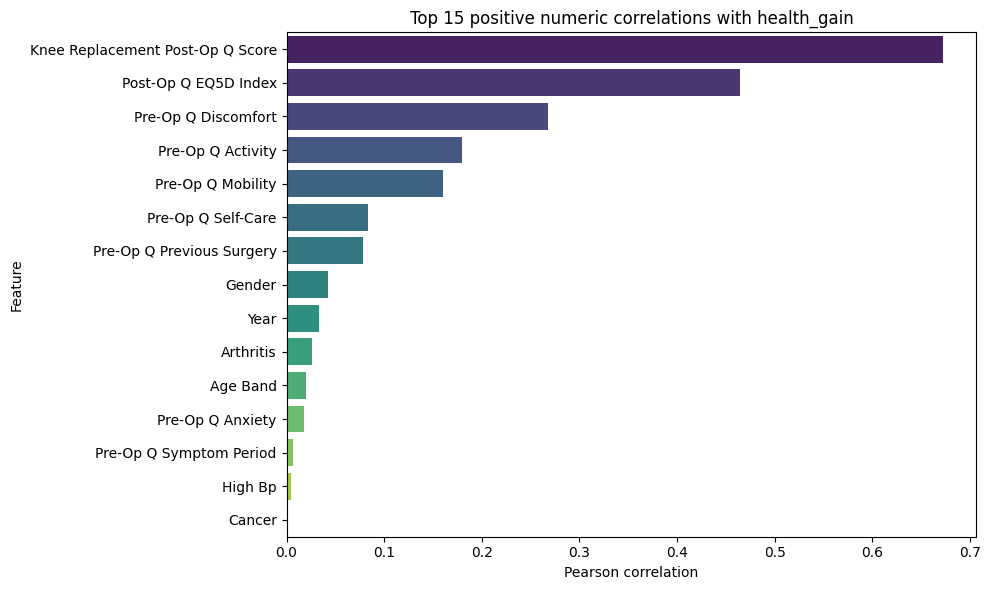

C:\Users\jkrin\AppData\Local\Temp\ipykernel_24892\2149507075.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd.DataFrame({'corr': top_neg.values, 'feature': top_neg.index}),


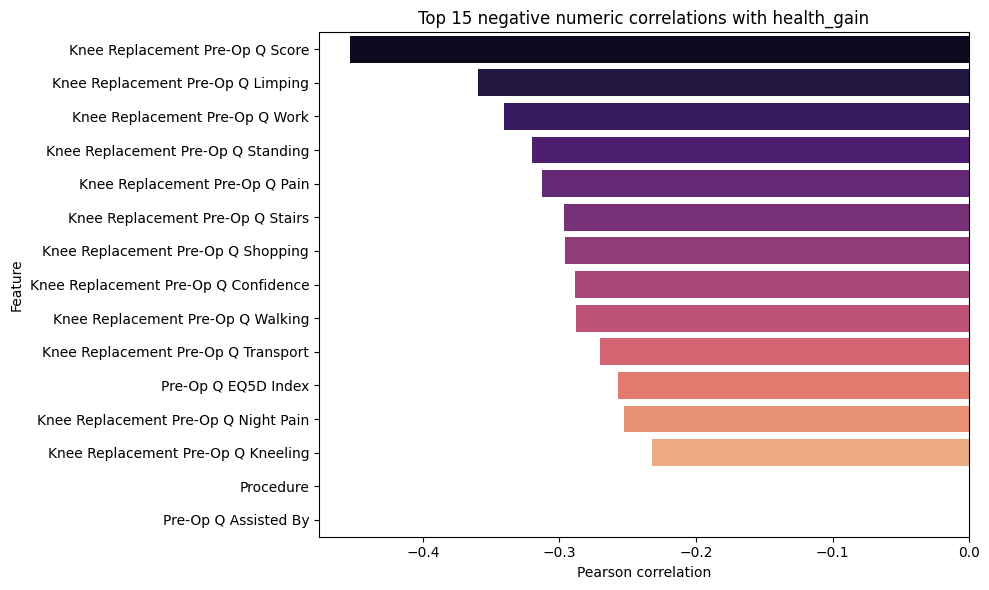

In [12]:
# Determine available target (prefer Health Gain)
candidates = [
    'health_gain'
]

target = next((c for c in candidates if c in train_df.columns), None)
if target is None:
    raise RuntimeError('No known regression target in data columns.')

print('Selected target:', target)

# If the target is already present in the test split this is regression evaluation directly.

# Check distribution
sns.histplot(train_df[target].dropna(), kde=True, bins=30)
plt.title(f'{target} Distribution (Train)')
plt.ylabel('Count'); plt.xlabel(target)
plt.show()

print('Target stats (train):', train_df[target].describe())

# Correlation analysis: health gain (or selected numeric target) vs numeric predictors
corr_df = train_df.select_dtypes(include=['number']).corr()[target].drop(index=[target]).sort_values(ascending=False)
print('Top 15 positive correlations with target:')
print(corr_df.head(15))
print('\nTop 15 negative correlations with target:')
print(corr_df.tail(15))

plt.figure(figsize=(10, 6))
top_pos = corr_df.head(15)
sns.barplot(data=pd.DataFrame({'corr': top_pos.values, 'feature': top_pos.index}), 
            x='corr', y='feature', palette='viridis')
plt.title(f'Top 15 positive numeric correlations with {target}')
plt.xlabel('Pearson correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
top_neg = corr_df.tail(15).sort_values()  # sort ascending so negative values appear correctly
sns.barplot(data=pd.DataFrame({'corr': top_neg.values, 'feature': top_neg.index}), 
            x='corr', y='feature', palette='magma')
plt.title(f'Top 15 negative numeric correlations with {target}')
plt.xlabel('Pearson correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 3.2 Feature matrix construction

In [13]:
# Remove target and known non-predictive columns
drop_cols = [target, 'OHS_Success'] if 'OHS_Success' in train_df.columns else [target]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target]

# Identify numeric and categorical features
numeric_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Numeric features:', len(numeric_cols), 'Categorical features:', len(cat_cols))
print('Sample numeric cols:', numeric_cols[:15])
print('Sample categorical cols:', cat_cols[:10])

Numeric features: 45 Categorical features: 2
Sample numeric cols: ['Arthritis', 'Cancer', 'Circulation', 'Depression', 'Diabetes', 'Heart Disease', 'High Bp', 'Kidney Disease', 'Liver Disease', 'Lung Disease', 'Nervous System', 'Stroke', 'Pre-Op Q Assisted', 'Pre-Op Q Previous Surgery', 'Age Band']
Sample categorical cols: ['Pre-Op Q EQ5D Index Profile', 'Post-Op Q EQ5D Index Profile']


C:\Users\jkrin\AppData\Local\Temp\ipykernel_24892\114443818.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


In [17]:
# If there are categorical columns, attempt one-hot encoding and imputation
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

transformers_list = []

# Add numeric transformer if numeric columns exist
if numeric_cols:
    transformers_list.append(('num', numeric_transformer, numeric_cols))

# Add categorical transformer if categorical columns exist
if cat_cols:
    categorical_transformer = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]
    )
    transformers_list.append(('cat', categorical_transformer, cat_cols))

# Create preprocessor with at least one transformer
if transformers_list:
    preprocessor = ColumnTransformer(
        transformers=transformers_list,
        remainder='drop'
    )
else:
    raise ValueError("No numeric or categorical columns found!")

print('Preprocessor configured.')

Preprocessor configured.


## 4. Regression models training + evaluation

Compare baseline and tree-based models with cross-validation and final test set metrics.

In [ ]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.01, random_state=42, max_iter=10000),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=300, random_state=42)
}

cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
scoring = {'MAE':'neg_mean_absolute_error', 'RMSE':'neg_root_mean_squared_error', 'R2':'r2'}

results = []

for name, model in models.items():
    pipeline_model = Pipeline([('pre', preprocessor), ('model', model)])
    cv_res = cross_validate(pipeline_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)

    results.append({
        'model': name,
        'MAE': -cv_res['test_MAE'].mean(),
        'RMSE': -cv_res['test_RMSE'].mean(),
        'R2': cv_res['test_R2'].mean()
    })

cv_results_df = pd.DataFrame(results).sort_values('RMSE')
cv_results_df

c:\Users\jkrin\.pyenv\pyenv-win\versions\3.12.2\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
6 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\jkrin\.pyenv\pyenv-win\versions\3.12.2\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\jkrin\.pyenv\pyenv-win\versions\3.12.2\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jkrin\.pyenv\pyenv-win\versions\3.1

## 5. Final fit on train, evaluate on test set

In [ ]:
# Choose best model by RMSE in CV
best_name = cv_results_df.sort_values('RMSE').iloc[0]['model']
best_estimator = models[best_name]
print('Best candidate:', best_name)

best_pipeline = Pipeline([('pre', preprocessor), ('model', best_estimator)])
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print('Test results:')
print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

# Save test metrics
test_metrics = pd.DataFrame([{
    'model': best_name,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
}])

display(test_metrics)

In [ ]:
# Residual analysis
resid = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=resid, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title(f'Residual plot for {best_name}')
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(resid, bins=40, edgecolor='k', alpha=0.6)
plt.title('Residual distribution')
plt.show()

## 6. Explainability (feature importance + SHAP)

In [ ]:
# Feature importance for tree models
if hasattr(best_pipeline.named_steps['model'], 'feature_importances_'):
    ff = best_pipeline.named_steps['model']
    # reconstruct feature names after preprocessing
    onehot_cols = []
    if cat_cols:
        encoder = best_pipeline.named_steps['pre'].named_transformers_['cat'].named_steps['onehot']
        cat_names = encoder.get_feature_names_out(cat_cols)
        onehot_cols = cat_names.tolist()
    feature_names = numeric_cols + onehot_cols

    importances = pd.Series(ff.feature_importances_, index=feature_names).sort_values(ascending=False)
    display(importances.head(25))

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances.head(20), y=importances.head(20).index)
    plt.title('Top 20 feature importances')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('No tree feature_importances_ available for', best_name)

# SHAP analysis if available and model supports
if shap is not None:
    print('Running SHAP explanation (takes a moment)...')
    explainer = shap.Explainer(best_pipeline.named_steps['model'], best_pipeline.named_steps['pre'].transform(X_train))
    shap_values = explainer(best_pipeline.named_steps['pre'].transform(X_test))

    shap.summary_plot(shap_values, feature_names=feature_names, plot_type='bar', show=True)
    shap.summary_plot(shap_values, feature_names=feature_names, show=True)
else:
    print('SHAP not installed; install with `pip install shap` to enable this section.')

## 7. Save best pipeline and metrics

In [ ]:
import joblib
out_dir = Path('c:/Users/jkrin/OneDrive/Documenten/EAISI/2. Applications/Group Project - NHS/EAISI-NHS/models')
out_dir.mkdir(parents=True, exist_ok=True)

pipe_path = out_dir / f'3.2-best-regressor-{best_name}.joblib'
metrics_path = out_dir / '3.2-regression-metrics.csv'

joblib.dump(best_pipeline, pipe_path)
print('Saved best model to', pipe_path)

test_metrics.to_csv(metrics_path, index=False)
print('Saved test metrics to', metrics_path)